# Week 5: From Intermolecular Interactions to Dynamics at the Atomistic Scale

## Molecular Dynamics, Newton's Second Law and The Equations of Motion
In MD simulations, atoms are treated as point particles evolving in time and space by following the principles of classical mechanics.  
Newton's Second Law describes how the velocity of a particle changes when it is subjected to an external force, and in particular - when a force of magnitude $\textbf{F}$ is exerted on a body $i$, it results in acceleration $\textbf{a}$ according to:

$$
	\textbf{a}=\frac{\textbf{F}}{m_i}
$$

where $m_i$ is the mass of the given particle.

At any given time $\textit{t}$ the position of A in Cartesian space is defined by the vector $\textbf{r}(t)=\left[x(t),y(t),z(t)\right]$. 

The velocity of particle $i$, $\textbf{v}(t)$, is the derivative of the position vector with respect to time, while the acceleration $\textbf{a}(t)$ is the derivative of the velocity with respect to time. 

For a system containint N-particles, the equations of motion read:
$$
\textbf{v}_i=\frac{\text{d}\textbf{r}_i}{\text{d}t}
$$

$$
\textbf{F}_i={m_i}{\frac{\text{d}\textbf{v}_i}{\text{d}t}}
$$

Given a set of initial positions $\{\mathbf{r_1}(0),\mathbf{r}_2(0)...\mathbf{r}_N(0)\}$ and velocities $\{\mathbf{v_1}(0),\mathbf{v}_2(0)...\mathbf{v}_N(0)\}$, the time evolution of the system can be computed by solving the equations of motion. 

An exact solution of the equations cannot be computed in the general case of system composed on $N$ particles system, therefore numerical schemes, commonly based on Taylor series expansion are used. 

## MD Simulations Algorithm 

The MD algorithm consists of a few conceptual steps: 
- system initialisation
- computing of the forces
- integrating the equations of motion
- computation and output of ensemble properties


```{prf:algorithm} MD Algorithm
:label: MD Simulations

**Inputs** A set of particles, their interaction potential, a set of initial conditions (positions, velocities)

**Output** A trajectory of the set of particles.

1. System initialisation
2. While time < total simulation time:
    1. For all pairs of particles:
       - Compute the interparticle forces 
	2. Integrate the equations of motion 
    3. Compute configurational properties  
3. Compute Ensemble Averages		

```







### System Initialization
Initialising the system requres defining/identifying: 
- A Force Field (FF). A FF is a mathematical formulation of the interaction potential $V$, complete with parameters that capture the physics of specific interatomic interactions. It includes functions accounting for non-bonded interactions, such as the Lennard-Jones potential, and bonded interaction functions, such as the harmonic potential. The force field is an important component of an MD simulation, and force fields are validated by comparing system properties to experimental data or \textit{ab-initio} calculations to ensure a physically meaningful system representation. 


- The initial conditions: initial positions and velocities to all particles in the system.
- Parameters such as number of particles, temperature, time step etc.


### Forces Calculation  
The second step of the algorithm involves calculating the force acting on every particle according to:

$$
\textbf{F}_i = -\frac{\partial V}{\partial \textbf{r}_i} = \bf{F}_{i,bonded} + \sum_j{ \bf{F}_{ij,non-bonded}} + \bf{F}_{ext}
$$


The force is computed each time step $\Delta t$. Typically, for computational efficiency, the contribution to the force on particle $i$ due to all its neighbours is considered within a cut-off radius. 

The term ${F}_{i,bonded}$ refers to intramolecular interactions, i.e. interactions between atoms belonging to the same molecule and determine the intramolecular motions such as bond stretching, angle bending, and dihedral torsional rotations. As the atoms involved in a bond, angle or dihedral are considered to oscillate around the equilibrium position, these motions are usually described by a harmonic potential.

### Dynamics Propagation
After the forces have been obtained, the movement of the atoms is propagated by numerically solving the equations of motion. A number of algorithms have been designed to integrate the equations of motion which provide different level of accuracy depending on their application. 
Commonly used are methods based on the Verlet algorithm. This algorithm is a combination of Taylor expansions, allowing to compute the atomic positions at time $(t+\Delta t)$ based on the atomic positions at time $t$ and $(t-\Delta t)$. The key equation of the Verlet algorithm is:  

$$
r\left(t+\Delta t\right) = 2r(t) -r(t-\Delta{t}) +\frac{{\Delta{t}}^2}{m}\textbf {F}(t)
$$


## Example 1: The Harmonic Oscillator:

In [6]:
%matplotlib inline
## Import libraries to plot and do math
import matplotlib.pyplot as plt 
import numpy as np

## Setup parameters of the HA
m=1.0; #mass
k=5; #Harmonic Constant
req=1.5; #Equilirbium 
##

## Set the initial Conditions
r0=1.0; # Initial position
v0=.1;  # Initial velocity

## Define the timestep and the total time
dt=0.05; #timestep
total_time=20; 
# Compute the total number of steps
nsteps=int(total_time/dt); # Total number of steps

## Initialise vectors 
v=np.zeros(nsteps)
r=np.zeros(nsteps)
time=np.zeros(nsteps)
POT=np.zeros(nsteps)
KIN=np.zeros(nsteps)

## Definition of useful functions. 

### Calculation of the force and potential energy

The force is computed as the negative of the potential derivative with respect to the degree of the degree of freedom. 

The potential is $V(r(t))=\frac{1}{2}k(r(t)-req)^2$, hence the force is: 

$$
F(t)=-\frac{\partial{V(r(t))}}{\partial{r(t)}}=-k(r(t)-req)
$$ 

In the code below the function computing the force is implemented as: 

```force=lambda r, k, req, : -k*(r-req)```

and the function computing the potential energy is defined as: 

```energy_pot=lambda r, k, req: 0.5*k*np.power(r-req,2)```

### Calculation of the velocity and kinetic energy

The velocity at time $t$, $v(t)$ is computed as: 

$$v(t)=\frac{r(t+\Delta{t})-r(t-\Delta{t})}{2\Delta{t}}$$ 

```velocity=lambda r, r_past, dt: (r-r_past)/2/dt```

The kinetic energy $K(v)=\frac{1}{2}mv^2$

```energy_kin=lambda v, m: 0.5*m*np.power(v,2)```

### Propagation of the system's dynamics: 

We use the Verlet algorithm: 

$$
r(t+\Delta{t})=2r(t)-r(t-\Delta{t})+\frac{F(t)}{m}\Delta{t}^2
$$

implemented as: 

```verlet=lambda r, r_past, force, mass, dt:  2*r-r_past+(dt**2)*force/mass```

In [7]:
## Useful functions
force=lambda r, k, req, : -k*(r-req)
energy_pot=lambda r, k, req: 0.5*k*np.power(r-req,2)
velocity=lambda r, r_past, dt: (r-r_past)/2/dt
energy_kin=lambda v, m: 0.5*m*np.power(v,2)
verlet=lambda r, r_past, force, mass, dt:  2*r-r_past+(dt**2)*force/mass

# initialise position and velocity

time[0]=0;
time[1]=dt;
v[0]=v0;
r[0]=r0;
r[1]=r[0]+v[0]*dt
v[1]=velocity(r[0],r[1],dt);

for i in np.arange(0,2):
    POT[i]=energy_pot(r[i],k,req)
    KIN[i]=energy_kin(v[i],m)

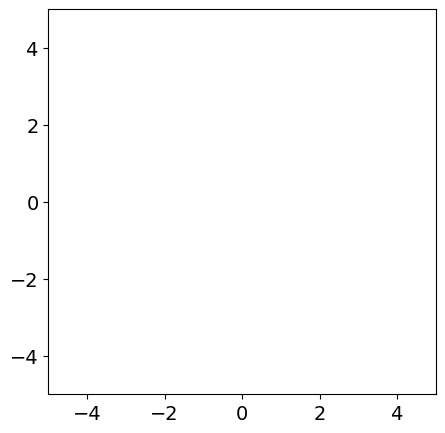

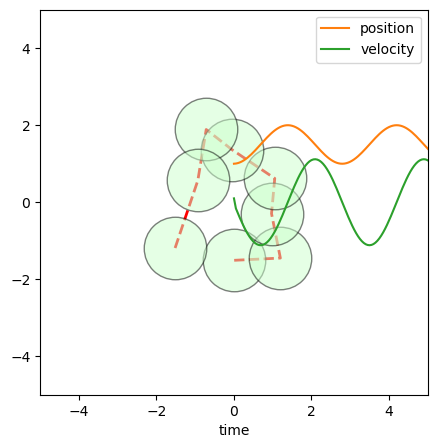

In [8]:
# Compute trajectory
for ts in np.arange(1,nsteps-1): #Cycle over timesteps
    
    f=force(r[ts],k,req) # Compute the force 
     
    r[ts+1]=verlet(r[ts],r[ts-1],f,m,dt) # Compute the next position
    time[ts+1]=time[ts]+dt # update the clock
    
    v[ts]=velocity(r[ts-1],r[ts+1],dt) # compute the velocity     
    POT[ts]=energy_pot(r[ts],k,req)  # compute the Potential Energy     
    KIN[ts]=energy_kin(v[ts],m)      # compute the Kinetic Energy    
    
v[ts+1]=v[ts]

plt.plot(time,r,label='position');
plt.plot(time,v,label='velocity');
plt.legend();
plt.xlabel('time');
plt.show()


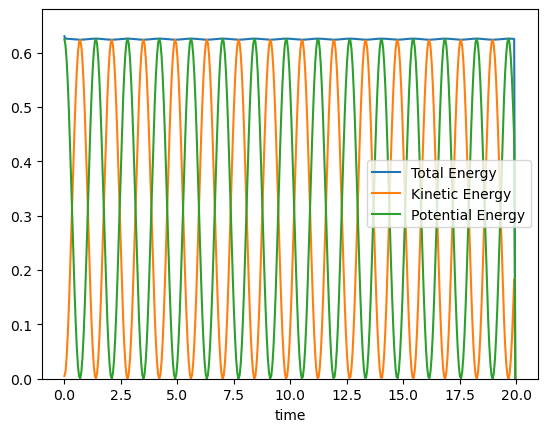

In [9]:
# Conservation of energy
plt.plot(time,POT+KIN,label='Total Energy')
plt.plot(time,KIN,label='Kinetic Energy')
plt.plot(time,POT,label='Potential Energy')
plt.ylim([0, np.max(POT+KIN)+0.05])
plt.legend()
plt.xlabel('time');
plt.show()

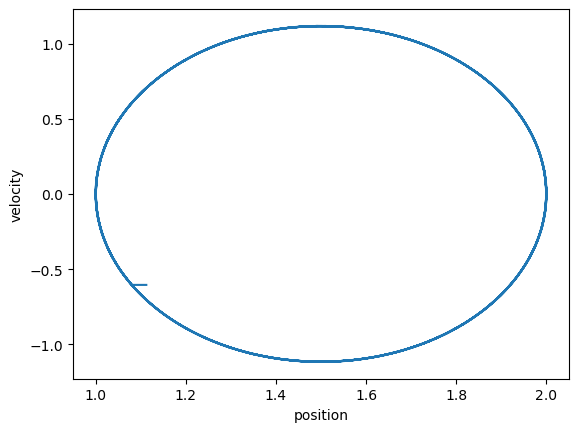

In [10]:
# Motion in phase space
plt.plot(r[10:],v[10:])
plt.xlabel('position');
plt.ylabel('velocity');
plt.show()


In [11]:
%%capture
# Visualize trajectory
%matplotlib inline
from matplotlib import animation, rc
from IPython.display import HTML


# Animate the results
def init():
    line.set_data([], [])
    return (line,)

fig, ax = plt.subplots(figsize=(8, 5))

#ax.set_xlim(( 0, total_time))
ax.set_xlim(-(np.max(r)/2+0.1*np.max(r)), np.max(r)/2+0.1*np.max(r))
line, = ax.plot([], [], lw=2, marker='o', markersize=45, markerfacecolor=(0.8, 1.0, 0.8, 0.5),
             markeredgewidth=1,  markeredgecolor=(0, 0, 0, .5), linestyle='-.',color='r')

def animate(i):
    x = np.array([-r[i]/2,r[i]/2])
    y = np.array([0,0])
    line.set_data(x, y)
    return (line,)

# call the animator. blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=np.arange(1,nsteps,50), interval=10, blit=True)

                               

In [12]:
HTML(anim.to_jshtml())

## Example 2: A pseudo-molecule in 2D. 

In the following example the Verlet algorithm is used to propagate the dynamics of a pseudo-molecule in two dimensions. This pseudo-molecule is defied as a chain of particles connected by harmonic bonds. Particles are prevented from overlapping by a repulsive core potential. 

The Harmonic bond potential has the form: 

$$
U^{bond}_{i,j} = \frac{1}{2}k\left(r_{i,j}-r_{eq}\right)^2
$$

where $r_{i,j}$ is the distance between particles $i$ and $j$ and $r_{eq}$ is the bond equilibrium distance. 

The repulsive core interaction potential between particles is defined as: 

$$
U^{rep}_{i,j} = \frac{C_{rep}}{r_{i,j}^2}
$$

In the following a python implementation of the Verlet algorithm is reported and commented: 

In [40]:

#Import libraries
import matplotlib.pyplot as plt 
from matplotlib import cm
import numpy as np

## Initial conditions
# positions
x0=np.array([1, 2, 3, 4, 4, 3, 1, 1]);       
y0=np.array([1, 1.5, 1, 1.5, 2, 2.5, 2, 2.5]);

# Random initial velocities
v0=0.25*(np.random.rand(2,8)-0.5);

# timestep
dt=0.02;

#mass of the particles
m=np.array([1,1,1,1,1,1,1,1]);

#number of iterations
final_time=10;
NS=final_time/dt; 
nsteps=np.round(NS); 

#Interatomic potential constants
k=25.0; # Harmonic oscillator constant
req=1; # Harmonic oscillator equilibrium distance
Crep=10; # Repulsive soft potential 

# Topology: 1 indicates that two particles are connected by a Harmonic spring. 
M=np.array([[0, 1, 0, 0, 0, 0, 0, 1],
           [1, 0, 1, 0, 0, 0, 0, 0],
           [0, 1, 0, 1, 0, 0, 0, 0],
           [0, 0, 1, 0, 1, 0, 0, 0],
           [0, 0, 0, 1, 0, 1, 0, 0],
           [0, 0, 0, 0, 1, 0, 1, 0],
           [0, 0, 0, 0, 0, 1, 0, 1],
           [1, 0, 0, 0, 0, 0, 1, 0]]); 

k=k*M;

### Initialization

In [36]:
%%capture
%matplotlib inline

# Setup figure for plotting the trajectory
figure, axes = plt.subplots(figsize=(5, 5))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
axes.set_xlim([-5,5]);
axes.set_ylim([-5,5]);

## Compute a trajectory with the Verlet Algorithm
# Initialise positions at t-dt
xp=x0;
yp=y0;

# Position at time t
x=xp+v0[0,:]*dt;
y=yp+v0[1,:]*dt;

# Position at time t+dt
xnew=np.zeros(np.shape(x0));
ynew=np.zeros(np.shape(x0));

# time
time=np.arange(0,nsteps);

xx=np.zeros((np.size(time),np.size(x)));xx[0]=x0
yy=np.zeros((np.size(time),np.size(y)));yy[0]=y0
time[0]=0;
time[1]=time[0]+dt;

# Initialise Energy Potential and Kinetic
POT=np.zeros(np.shape(time));
KIN=np.zeros(np.shape(time));

## Trajectory calculation   

In [37]:
# Compute trajectory
for timestep in np.arange(1,nsteps): #Cycle over timesteps
    timestep=int(timestep)           #Make sure timestep is an integer
    
    # Initialise force vectors
    fx=np.zeros(np.size(x0));  
    fy=np.zeros(np.size(x0)); 
    
    # Compute distances and the interparticle forces for every pair of particles
    for i in np.arange(0,np.size(x0)):
        for j in np.arange(i+1,np.size(x0)):
            
            r=np.sqrt((x[i]-x[j])*(x[i]-x[j])+(y[i]-y[j])*(y[i]-y[j])); #Distance    
            
            temp=-(k[i,j]*(r-req)-2*Crep/(np.power(r,3)))

            cx=temp*((x[i]-x[j]))/r;  #Pairwise force in x
            cy=temp*((y[i]-y[j]))/r;  #Pairwise force in y
                
            fx[i]=fx[i]+cx;      #update total x-component of the force on particle i
            fx[j]=fx[j]-cx;      #update total x-component of the force on particle j 

            fy[i]=fy[i]+cy;      #update total y-component of the force on particle i
            fy[j]=fy[j]-cy;      #update total y-component of the force on particle j 
           
       
    #Verlet integration
    for i in np.arange(0,np.size(x0)):
        xnew[i]=2*x[i]-xp[i]+(dt*dt)*fx[i]/m[i]; # new position (x-component)
        ynew[i]=2*y[i]-yp[i]+(dt*dt)*fy[i]/m[i]; # new position (y-component)
    
    # Compute velocity     
    vx=(xnew-xp)/2/dt;
    vy=(ynew-yp)/2/dt;
    v=np.sqrt(np.power(vx,2)+np.power(vy,2)); 
    
    # Reassign positions
    xp=x; yp=y; x=xnew-np.mean(xnew); y=ynew-np.mean(ynew);
    
    ## Store trajectory for animation 
    xx[timestep]=x;
    yy[timestep]=y;

In [38]:
%%capture
%matplotlib inline
from matplotlib.animation import FuncAnimation
from matplotlib import animation, rc
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(5, 5))
line, = ax.plot([]) 
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
line, = ax.plot([], [], lw=2, marker='o', markersize=45, markerfacecolor=(0.8, 1.0, 0.8, 0.5),
             markeredgewidth=1,  markeredgecolor=(0, 0, 0, .5), linestyle='--',color='red')


# initialization function: plot the background of each frame
def init():
    line.set_data([], [])
    return (line,)

def animate(frame_num):
    x=xx[frame_num,:]
    y=yy[frame_num,:]
    line.set_data((x, y))
    return (line,)

# call the animator. blit=True means only re-draw the parts that have changed.
anim2 = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=np.size(np.arange(1,nsteps)), interval=50);



In [39]:

HTML(anim2.to_jshtml())